**import libraries**

In [2]:
!pip install -q opencv-python scikit-image seaborn

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries loaded successfully.")

Libraries loaded successfully.


**DATA SET IMPORT**

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [5]:
dataset_path = Path("/kaggle/input/chest-xray-pneumonia/chest_xray")

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")

    for category in ["NORMAL", "PNEUMONIA"]:
        folder = dataset_path / split / category

        images = list(folder.glob("*"))

        print(category, ":", len(images))


TRAIN
NORMAL : 1341
PNEUMONIA : 3875

VAL
NORMAL : 8
PNEUMONIA : 8

TEST
NORMAL : 234
PNEUMONIA : 390


**Visualize X-rays**

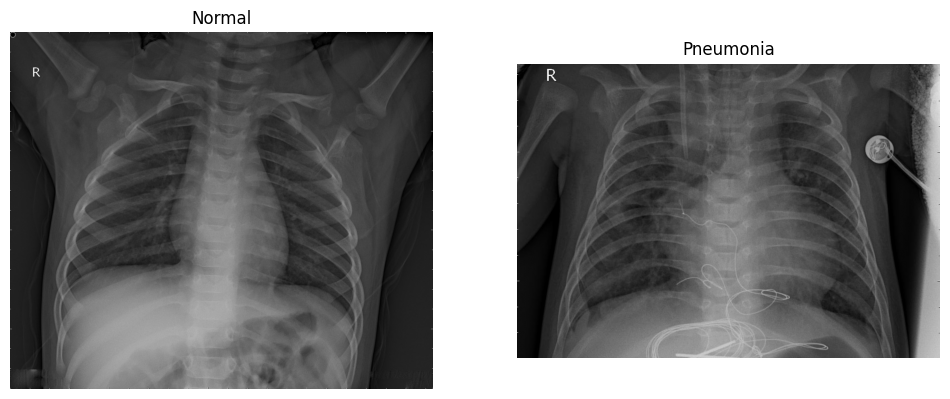

In [6]:
normal_folder = dataset_path / "train" / "NORMAL"
pneumonia_folder = dataset_path / "train" / "PNEUMONIA"

normal_images = list(normal_folder.glob("*"))
pneumonia_images = list(pneumonia_folder.glob("*"))

normal_img = cv2.imread(str(normal_images[0]), cv2.IMREAD_GRAYSCALE)
pneumonia_img = cv2.imread(str(pneumonia_images[0]), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal_img, cmap="gray")
plt.title("Normal")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_img, cmap="gray")
plt.title("Pneumonia")
plt.axis("off")

plt.show()

implement CLAHE

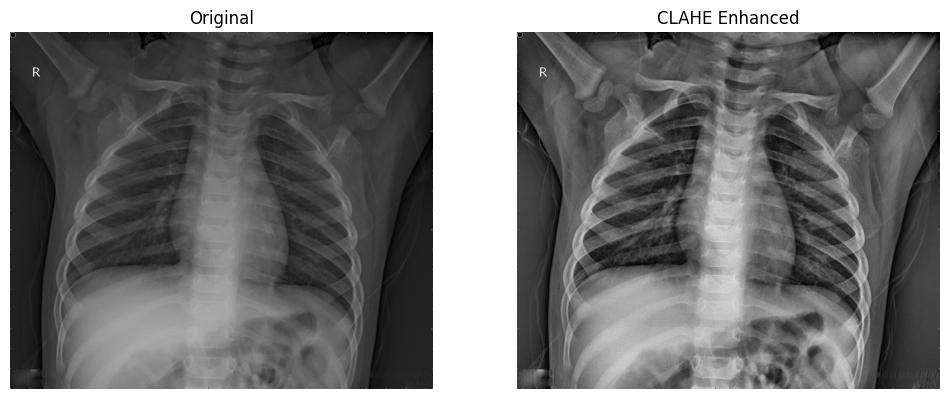

In [7]:
def apply_clahe(image):
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    return clahe.apply(image)

enhanced = apply_clahe(normal_img)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal_img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.show()

**preprocessing function**

In [8]:
IMG_SIZE = 224

def preprocess_image(image_path):
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        return None

    # Resize
    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # CLAHE
    image = apply_clahe(image)

    # Normalize to 0-1
    image = image.astype(np.float32) / 255.0

    return image

In [9]:
processed = preprocess_image(normal_images[0])

print(processed.shape)
print(processed.min())
print(processed.max())

(224, 224)
0.003921569
1.0


**Prepare PyTorch**

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

In [11]:
class PneumoniaDataset(Dataset):

    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)

        self.samples = []

        # Normal = 0
        normal_dir = self.root_dir / "NORMAL"

        for image_path in normal_dir.glob("*"):
            self.samples.append(
                (image_path, 0)
            )

        # Pneumonia = 1
        pneumonia_dir = self.root_dir / "PNEUMONIA"

        for image_path in pneumonia_dir.glob("*"):
            self.samples.append(
                (image_path, 1)
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = preprocess_image(image_path)

        # Add channel dimension
        image = np.expand_dims(image, axis=0)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label

**Create train datasets**

In [12]:
train_dataset = PneumoniaDataset(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
)

val_dataset = PneumoniaDataset(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
)

test_dataset = PneumoniaDataset(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/test"
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Training: 5216
Validation: 16
Testing: 624


**Create DataLoaders**

In [13]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

**Load ResNet18**

In [14]:
images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([32, 1, 224, 224])
Label batch: torch.Size([32])


In [15]:
images = images.repeat(1, 3, 1, 1)

print(images.shape)

torch.Size([32, 3, 224, 224])


In [16]:
import torchvision
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.resnet18(
    weights="DEFAULT"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


In [17]:
num_features = model.fc.in_features

model.fc = torch.nn.Linear(
    num_features,
    2
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**Loss function and optimizer**

In [18]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

**Training function**

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.repeat(1, 3, 1, 1)

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = correct / total

    return running_loss / len(loader), accuracy

**Validation function**

In [20]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.repeat(1, 3, 1, 1)

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = correct / total

    return running_loss / len(loader), accuracy

In [22]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

**Train the model**

In [23]:
EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation Accuracy: {val_acc:.4f}"
    )

    print("-" * 50)

Epoch 1/10
Train Loss: 0.0138 | Train Accuracy: 0.9956
Validation Loss: 0.1935 | Validation Accuracy: 0.9375
--------------------------------------------------
Epoch 2/10
Train Loss: 0.0131 | Train Accuracy: 0.9946
Validation Loss: 0.0014 | Validation Accuracy: 1.0000
--------------------------------------------------
Epoch 3/10
Train Loss: 0.0044 | Train Accuracy: 0.9992
Validation Loss: 0.0089 | Validation Accuracy: 1.0000
--------------------------------------------------
Epoch 4/10
Train Loss: 0.0068 | Train Accuracy: 0.9977
Validation Loss: 0.0126 | Validation Accuracy: 1.0000
--------------------------------------------------
Epoch 5/10
Train Loss: 0.0109 | Train Accuracy: 0.9958
Validation Loss: 1.3325 | Validation Accuracy: 0.5625
--------------------------------------------------
Epoch 6/10
Train Loss: 0.0038 | Train Accuracy: 0.9987
Validation Loss: 0.0135 | Validation Accuracy: 1.0000
--------------------------------------------------
Epoch 7/10
Train Loss: 0.0020 | Train Ac

# calculate:

Precision,
Recall,
F1,
Confusion matrix,
ROC-AUC,
learning curve

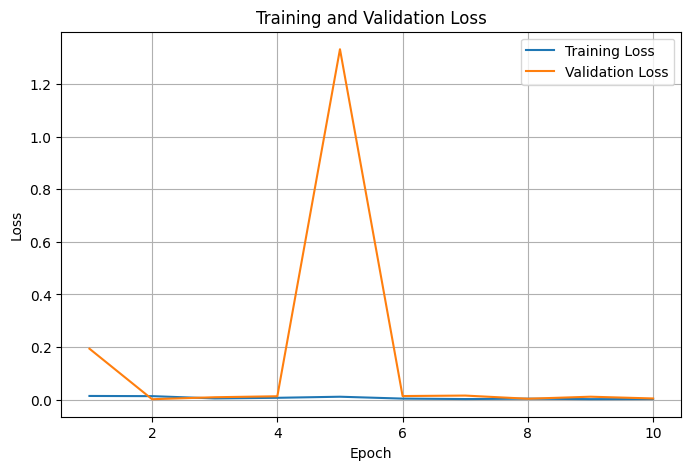

In [24]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

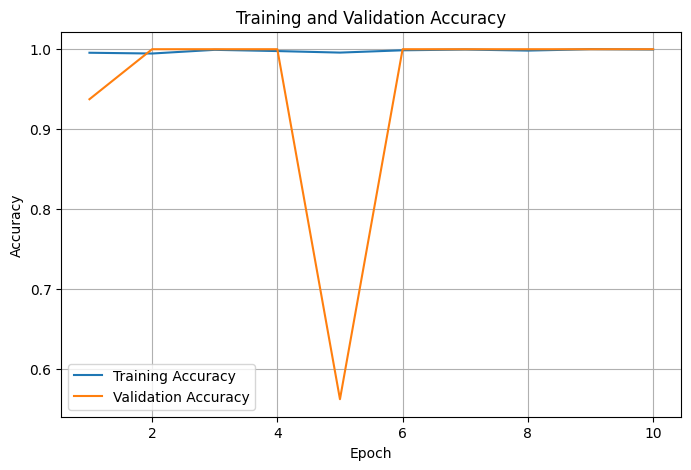

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [26]:
def evaluate_model(model, loader):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.repeat(1, 3, 1, 1)

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions
    )

    recall = recall_score(
        all_labels,
        all_predictions
    )

    f1 = f1_score(
        all_labels,
        all_predictions
    )

    auc = roc_auc_score(
        all_labels,
        all_probabilities
    )

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", auc)

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=[
                "Normal",
                "Pneumonia"
            ]
        )
    )

    return (
        all_labels,
        all_predictions,
        all_probabilities
    )

In [27]:
y_true, y_pred, y_prob = evaluate_model(
    model,
    test_loader
)

Accuracy : 0.7916666666666666
Precision: 0.750965250965251
Recall   : 0.9974358974358974
F1 Score : 0.8568281938325991
ROC-AUC  : 0.916151654613193

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.45      0.62       234
   Pneumonia       0.75      1.00      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.72      0.74       624
weighted avg       0.84      0.79      0.77       624



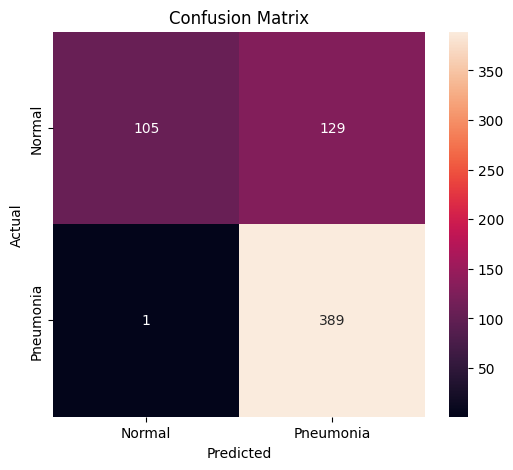

In [28]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Normal",
        "Pneumonia"
    ],
    yticklabels=[
        "Normal",
        "Pneumonia"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [29]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.repeat(1, 3, 1, 1)

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total

print("Test accuracy:", accuracy)
print("Test accuracy (%):", accuracy * 100)

Test accuracy: 0.7916666666666666
Test accuracy (%): 79.16666666666666


**Install Grad-CAM**

In [30]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [31]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

**final convolutional features of ResNet18**

In [32]:
target_layers = [model.layer4[-1]]

**function for Grad-CAM**

In [33]:
def generate_gradcam(model, image_tensor, target_class=None):

    model.eval()

    # Grad-CAM expects a batch
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Repeat grayscale channel to RGB
    input_tensor = input_tensor.repeat(1, 3, 1, 1)

    target_layers = [model.layer4[-1]]

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    if target_class is None:

        with torch.no_grad():
            output = model(input_tensor)

        target_class = output.argmax(
            dim=1
        ).item()

    targets = [
        ClassifierOutputTarget(target_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

    grayscale_cam = grayscale_cam[0]

    return grayscale_cam

In [34]:
image_path = pneumonia_images[0]

processed = preprocess_image(image_path)

image_tensor = torch.tensor(
    processed,
    dtype=torch.float32
)

**Generate the Grad-CAM**

In [35]:
cam = generate_gradcam(
    model,
    image_tensor
)

print(cam.shape)

(224, 224)


In [36]:
original_image = processed

# Convert grayscale to RGB
rgb_image = np.stack(
    [original_image] * 3,
    axis=-1
)

**Create the heatmap**

In [37]:
visualization = show_cam_on_image(
    rgb_image,
    cam,
    use_rgb=True
)

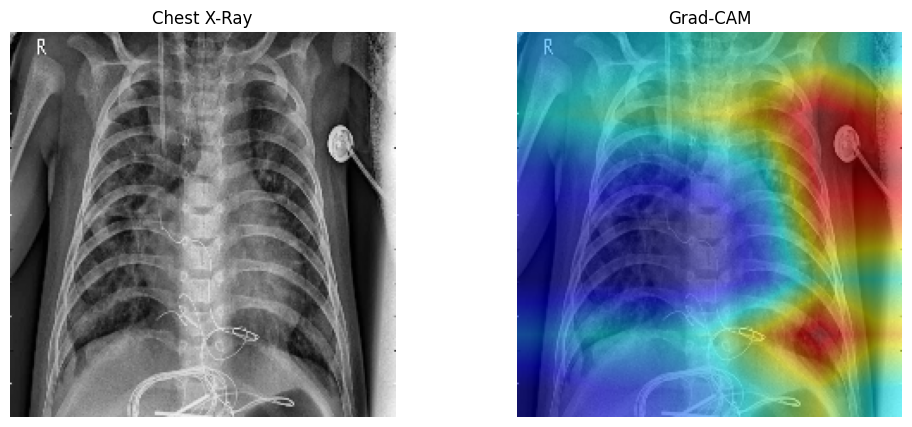

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Chest X-Ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

In [39]:
model.eval()

input_tensor = image_tensor.unsqueeze(0).to(device)

input_tensor = input_tensor.repeat(
    1, 3, 1, 1
)

with torch.no_grad():

    output = model(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    prediction = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0, prediction
    ].item()

In [40]:
classes = [
    "Normal",
    "Pneumonia"
]

print("Prediction:", classes[prediction])
print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

Prediction: Pneumonia
Confidence: 100.00%
